In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/v3')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.special import softmax
import torchcp
from data_config import get_config
import torch.optim as optim
from tqdm import tqdm


def platt_scale(logits, labels, max_iters=100, lr=0.01, epsilon=0.005):
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(logits),
                                             torch.from_numpy(labels).long()) 
    dataloader = torch.utils.data.DataLoader(dataset,
                                             batch_size=64,
                                             shuffle=True)

    nll_criterion = nn.CrossEntropyLoss().cuda()

    T = nn.Parameter(torch.Tensor([1.3]).cuda())
    optimizer = optim.SGD([T], lr=lr)
    for iter in tqdm(range(max_iters)):
        T_old = T.item()
        for x, targets in dataloader:
            optimizer.zero_grad()
            x = x.cuda()
            x.requires_grad = True
            out = x/T
            loss = nll_criterion(out, targets.long().cuda())
            loss.backward()
            optimizer.step()
        if abs(T_old - T.item()) < epsilon:
            break
    return T.item() 


In [2]:
config = get_config('cifar100_resnet56')
config.par_calib = 0.5
config.num_calib = int(config.num_samples * config.par_calib)
config.alpha = 0.1

In [3]:
with open(config.file_name, 'rb') as file:
    data = pickle.load(file)

labels_eval, labels_calib, scores_eval, scores_calib = train_test_split(
    data["labels"], data["preds"], test_size=config.par_calib, random_state=42
)

t = platt_scale(scores_calib, labels_calib, max_iters=10, lr=0.01, epsilon=0.01)
print(t)
scores_calib = scores_calib / t
scores_eval = scores_eval / t

scores_calib = torch.from_numpy(scores_calib)
scores_eval = torch.from_numpy(scores_eval)

labels_calib = torch.from_numpy(labels_calib)
labels_eval = torch.from_numpy(labels_eval)

 50%|█████     | 5/10 [00:00<00:00,  8.25it/s]

1.7254935503005981


In [4]:
import torch

from torchcp.classification.scores.base import BaseScore

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # if using GPU


class MyAPS(BaseScore):
    """
    Adaptive Prediction Sets (Romano et al., 2020)
    paper :https://proceedings.neurips.cc/paper/2020/file/244edd7e85dc81602b7615cd705545f5-Paper.pdf
    """

    def __call__(self, logits, label=None):
        assert len(logits.shape) <= 2, "dimension of logits are at most 2."
        if len(logits.shape) == 1:
            logits = logits.unsqueeze(0)
        probs = torch.softmax(logits, dim=-1)
        if label is None:
            return self._calculate_all_label(probs)
        else:
            return self._calculate_single_label(probs, label)

    def _calculate_all_label(self, probs):
        indices, ordered, cumsum = self._sort_sum(probs)
        U = torch.rand(probs.shape, device=probs.device)
        ordered_scores = cumsum - ordered * U
        _, sorted_indices = torch.sort(indices, descending=False, dim=-1)
        scores = ordered_scores.gather(dim=-1, index=sorted_indices)
        return scores

    def _sort_sum(self, probs):
        # ordered: the ordered probabilities in descending order
        # indices: the rank of ordered probabilities in descending order
        # cumsum: the accumulation of sorted probabilities
        ordered, indices = torch.sort(probs, dim=-1, descending=True)
        cumsum = torch.cumsum(ordered, dim=-1)
        return indices, ordered, cumsum

    def _calculate_single_label(self, probs, label):
        set_seed(42)
        indices, ordered, cumsum = self._sort_sum(probs)
        U = torch.rand(indices.shape[0], device=probs.device)
        idx = torch.where(indices == label.view(-1, 1))
        scores_first_rank = U * cumsum[idx]
        idx_minus_one = (idx[0], idx[1] - 1)
        scores_usual = U * ordered[idx] + cumsum[idx_minus_one]
        return torch.where(idx[1] == 0, scores_first_rank, scores_usual)


In [5]:
from torchcp.classification.predictors import SplitPredictor
from torchcp.classification.scores import APS, RAPS, SAPS
from predictor import SplitPredictorVectorThreshold
from torchcp.classification.utils.metrics import Metrics
metrics = Metrics()


eps = 1e-10

conf_score = SAPS(weight=1)
cal_scores_est = conf_score(scores_calib, scores_calib.argmax(1))
cal_scores_true = conf_score(scores_calib, labels_calib)
n = len(scores_calib)
normalizer = cal_scores_true.max()
residuales = (cal_scores_true - cal_scores_est) / (normalizer - cal_scores_est + eps)

print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))

qhat = np.quantile(
    residuales, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)

val_scores_est = conf_score(scores_eval, scores_eval.argmax(1))
val_scores_true = conf_score(scores_eval, labels_eval)
val_scores_est_copy = val_scores_est
val_scores_est = val_scores_est + qhat * (normalizer - val_scores_est + eps)
print('Par of scores above 1: {:.2f}'.format(torch.sum(val_scores_est > 1) / len(val_scores_est)))
predictor = SplitPredictorVectorThreshold(conf_score)
# predictor.set_deivce(torch.device('cpu'))
prediction_sets = predictor.predict_with_logits(scores_eval, val_scores_est)
res_dict = {
    "Coverage_rate": metrics('coverage_rate')(prediction_sets, labels_eval),
    "Average_size": metrics('average_size')(prediction_sets, labels_eval)}
print(res_dict)
print('qhat:', qhat)


Residuales: mean: 0.020 std: 0.076 min: -0.011 max: 1.000
Par of scores above 1: 1.00


{'Coverage_rate': 0.9036, 'Average_size': 3.7764}
qhat: 0.03750959


In [6]:
def _sort_sum(probs):
    indices = np.argsort(-probs, axis=1)  # Get the indices that would sort the array
    ordered = np.take_along_axis(probs, indices, axis=1)          # Sort the array using the indices
    cumsum = np.cumsum(ordered, axis=1)        # Compute the cumulative sum of the sorted array
    return indices, ordered, cumsum

def _sort_sum_torch(probs):
    # ordered: the ordered probabilities in descending order
    # indices: the rank of ordered probabilities in descending order
    # cumsum: the accumulation of sorted probabilities
    ordered, indices = torch.sort(probs, dim=-1, descending=True)
    cumsum = torch.cumsum(ordered, dim=-1)
    return indices, ordered, cumsum

probs = np.array([[0.2, 0.5, 0.1, 0.2],
                  [0.1, 0.2, 0.3, 0.4]])
probs_torch = torch.tensor(probs)

print(_sort_sum(probs))
print('\n\n')

print(_sort_sum_torch(probs_torch))

(array([[1, 0, 3, 2],
       [3, 2, 1, 0]]), array([[0.5, 0.2, 0.2, 0.1],
       [0.4, 0.3, 0.2, 0.1]]), array([[0.5, 0.7, 0.9, 1. ],
       [0.4, 0.7, 0.9, 1. ]]))



(tensor([[1, 0, 3, 2],
        [3, 2, 1, 0]]), tensor([[0.5000, 0.2000, 0.2000, 0.1000],
        [0.4000, 0.3000, 0.2000, 0.1000]], dtype=torch.float64), tensor([[0.5000, 0.7000, 0.9000, 1.0000],
        [0.4000, 0.7000, 0.9000, 1.0000]], dtype=torch.float64))


In [7]:
def _calculate_single_label_torch(probs, label):
    indices, ordered, cumsum = _sort_sum_torch(probs)
    U = torch.rand(indices.shape[0], device=probs.device)
    U = torch.zeros_like(U)
    idx = torch.where(indices == label.view(-1, 1))
    scores_first_rank = U * cumsum[idx]
    scores_usual = 1 * (idx[1] - U) + ordered[:, 0]
    return torch.where(idx[1] == 0, scores_first_rank, scores_usual)

def _calculate_single_label(probs, label):
    indices, ordered, cumsum = _sort_sum(probs)
    # Generate random values U from a uniform distribution with the same shape as the batch
    U = np.random.rand(*indices.shape)
    U = np.zeros_like(U)
    # Find the index where the sorted indices equal the label for each row
    idx = np.where(indices == label[:, np.newaxis])
    # Compute the scores
    scores_first_rank = U[idx] * cumsum[idx]
    scores_usual = 1 * (idx[1] - U[idx]) + ordered[:, 0]
    # Return the appropriate scores based on the condition
    return np.where(idx[1] == 0, scores_first_rank, scores_usual)



probs = np.array([[0.2, 0.5, 0.1, 0.2],
                  [0.1, 0.2, 0.3, 0.4]])
label = np.array([0,2])

print(_calculate_single_label_torch(torch.from_numpy(probs), torch.from_numpy(label)))
print(_calculate_single_label(probs, label))

tensor([1.5000, 1.4000], dtype=torch.float64)
[1.5 1.4]


In [8]:
def _calculate_all_label_torch(probs):
    indices, ordered, cumsum = _sort_sum_torch(probs)
    ordered[:, 1:] = 1
    cumsum = torch.cumsum(ordered, dim=-1)
    U = torch.rand(probs.shape, device=probs.device)
    U = torch.zeros_like(U)
    ordered_scores = cumsum - ordered * U
    _, sorted_indices = torch.sort(indices, descending=False, dim=-1)
    scores = ordered_scores.gather(dim=-1, index=sorted_indices)
    return scores

def _calculate_all_label(probs):
    indices, ordered, cumsum = _sort_sum(probs)
    # Set the weights for all but the first column
    ordered[:, 1:] = 1
    # Recalculate the cumulative sum with the new weights
    cumsum = np.cumsum(ordered, axis=-1)
    # Generate random values U from a uniform distribution with the same shape as probs
    U = np.random.rand(*probs.shape)
    U = np.zeros_like(U)
    # Calculate the ordered scores
    ordered_scores = cumsum - ordered * U
    # Sort indices to map back to the original order
    sorted_indices = np.argsort(indices, axis=-1)
    # Gather the scores according to the original indices
    scores = np.take_along_axis(ordered_scores, sorted_indices, axis=-1)
    return scores


probs = np.array([[0.2, 0.5, 0.1, 0.2],
                  [0.1, 0.2, 0.3, 0.4]])
label = np.array([0,2])

print(_calculate_all_label_torch(torch.from_numpy(probs)))
print(_calculate_all_label(probs))

tensor([[1.5000, 0.5000, 3.5000, 2.5000],
        [3.4000, 2.4000, 1.4000, 0.4000]], dtype=torch.float64)
[[1.5 0.5 3.5 2.5]
 [3.4 2.4 1.4 0.4]]


In [9]:
class MySAPS():
    def __init__(self, weight=1.0, randomized=True, no_zero_size_sets=True, seed=0):
        self.weight = weight
        self.randomized = randomized
        self.no_zero_size_sets = no_zero_size_sets
        self.seed = seed

    def _sort_sum(self, probs):
        indices = np.argsort(-probs, axis=1)  # Get the indices that would sort the array
        ordered = np.take_along_axis(probs, indices, axis=1)          # Sort the array using the indices
        cumsum = np.cumsum(ordered, axis=1)        # Compute the cumulative sum of the sorted array
        return indices, ordered, cumsum

    def get_scores(self, softmax_scores, labels):
        indices, ordered, cumsum = self._sort_sum(softmax_scores)
        # Generate random values U from a uniform distribution with the same shape as the batch
        U = np.random.rand(*indices.shape)
        # Find the index where the sorted indices equal the label for each row
        idx = np.where(indices == labels[:, np.newaxis])
        # Compute the scores
        scores_first_rank = U[idx] * cumsum[idx]
        scores_usual = self.weight * (idx[1] - U[idx]) + ordered[:, 0]
        # Return the appropriate scores based on the condition
        return np.where(idx[1] == 0, scores_first_rank, scores_usual)

    def get_sets(self, softmax_scores, qhat):
        indices, ordered, cumsum = self._sort_sum(softmax_scores)
        # Set the weights for all but the first column
        ordered[:, 1:] = 1
        # Recalculate the cumulative sum with the new weights
        cumsum = np.cumsum(ordered, axis=-1)
        # Generate random values U from a uniform distribution with the same shape as probs
        U = np.random.rand(*softmax_scores.shape)
        # Calculate the ordered scores
        ordered_scores = cumsum - ordered * U
        # Sort indices to map back to the original order
        sorted_indices = np.argsort(indices, axis=-1)
        # Gather the scores according to the original indices
        scores = np.take_along_axis(ordered_scores, sorted_indices, axis=-1)
        return scores <= qhat
        # indicators = [np.where(scores[i] <= qhat)[0].tolist() for i in range(scores.shape[0])]
        # np.



In [10]:
n = len(labels_calib)

np_scores_calib = scores_calib.cpu().numpy()
np_labels_calib = labels_calib.cpu().numpy()

np_scores_eval = scores_eval.cpu().numpy() 
np_labels_eval = labels_eval.cpu().numpy()

conf_score = MySAPS(1, randomized=True, no_zero_size_sets=True, seed=1)
cal_scores = conf_score.get_scores(np_scores_calib, np_labels_calib)
baseline_qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)
prediction_sets = conf_score.get_sets(np_scores_eval, baseline_qhat)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), np_labels_eval
].mean()

baseline_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Baseline mets:')
for key, value in baseline_mets.items():
    print(f"{key}: {value:.4f}")
print('Qhat: {:.4f}'.format(baseline_qhat))


Baseline mets:
size: 3.8494
coverage: 0.9006
Qhat: 11.5548


In [11]:
# baseline
baseline_predictor = SplitPredictor(SAPS(1))
baseline_predictor.calculate_threshold(scores_calib, labels_calib, config.alpha)
baseline_prediction_sets = baseline_predictor.predict_with_logits(scores_eval)
baseline_res_dict = {
    "Coverage_rate": metrics('coverage_rate')(baseline_prediction_sets, labels_eval),
    "Average_size": metrics('average_size')(baseline_prediction_sets, labels_eval)}
print(baseline_res_dict)
print(baseline_predictor.q_hat.item())


{'Coverage_rate': 0.9058, 'Average_size': 3.6766}
3.4191746711730957


In [12]:
# baseline
baseline_predictor = SplitPredictor(RAPS(1))
baseline_predictor.calculate_threshold(scores_calib, labels_calib, config.alpha)
baseline_prediction_sets = baseline_predictor.predict_with_logits(scores_eval)
baseline_res_dict = {
    "Coverage_rate": metrics('coverage_rate')(baseline_prediction_sets, labels_eval),
    "Average_size": metrics('average_size')(baseline_prediction_sets, labels_eval)}
print(baseline_res_dict)
print(baseline_predictor.q_hat.item())


{'Coverage_rate': 0.905, 'Average_size': 3.5326}
4.96901273727417


In [13]:
# baseline
baseline_predictor = SplitPredictor(APS())
baseline_predictor.calculate_threshold(scores_calib, labels_calib, config.alpha)
baseline_prediction_sets = baseline_predictor.predict_with_logits(scores_eval)
baseline_res_dict = {
    "Coverage_rate": metrics('coverage_rate')(baseline_prediction_sets, labels_eval),
    "Average_size": metrics('average_size')(baseline_prediction_sets, labels_eval)}
print(baseline_res_dict)
print(baseline_predictor.q_hat.item())


{'Coverage_rate': 0.9018, 'Average_size': 6.167}
0.9078089594841003


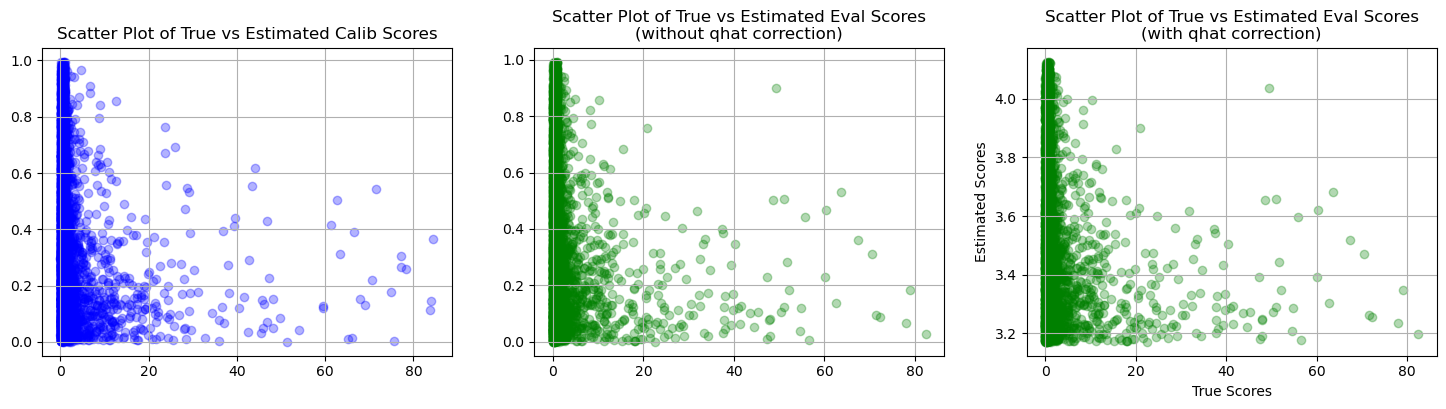

In [14]:
# debug #
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].scatter(cal_scores_true, cal_scores_est, color='blue', alpha=0.3)
ax[0].set_title('Scatter Plot of True vs Estimated Calib Scores')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
# ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].grid(True)

ax[1].scatter(val_scores_true, val_scores_est_copy, color='green', alpha=0.3)
ax[1].set_title('Scatter Plot of True vs Estimated Eval Scores\n(without qhat correction)')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
# ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].grid(True)

ax[2].scatter(val_scores_true, val_scores_est, color='green', alpha=0.3)
ax[2].set_title('Scatter Plot of True vs Estimated Eval Scores\n(with qhat correction)')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
# ax[2].plot([0, 1], [0, 1], 'r--')
ax[2].grid(True)
plt.show()
